# Comparison expression of promoters across growth conditions.

In [1]:
import numpy as np
import pandas as pd
from numba import njit

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
import glob as glob
import itertools

from matplotlib import font_manager
import os

font_path = "/Users/tomroeschinger/Library/Fonts/Lucida-Sans-Unicode-Regular.ttf" 
if os.path.exists(font_path):
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)

if os.path.exists(font_path):
    mpl.rcParams["font.family"] = "sans-serif",
    mpl.rcParams["font.sans-serif"] = prop.get_name()


Import metadata for growth conditions.

In [2]:
df_gc = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
df_gc.tail(5)

,Index,Condition,Description,Group
34,37,low phosphate,M9 Minimal Media with 0.5% Glucose to steady s...,Nutrient–mineral limitation
35,38,copper sulfate (2mM),M9 Minimal Media with 0.5% Glucose to steady s...,Metal & membrane stress
36,39,acetate,M9 Minimal Media with 0.5% Sodium Acetate,Carbon‐source
37,40,nitrate,M9 Minimal Media with 0.5% Glucose with 80mM P...,Osmotic & ionic stress
38,41,anaerobic + nitrate,M9 Minimal Media with 0.5% Glucose grown compl...,Anaerobic


Import mapping of barcodes to promoter variants.

In [3]:
df_map = pd.read_csv("../../data/mapping/mapped_barcodes_filtered.csv")
df_map

,Unnamed: 0,promoter,barcode,count,name
0,24,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAACTAACTCAACAACACCA,59,TSS_1414_storz_regulondb
1,25,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAATCGTAGCCCGTTCCTAC,80,TSS_1414_storz_regulondb
2,26,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAGCATTTCAACGGAGGACA,13,TSS_1414_storz_regulondb
3,27,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AAGCCTACCGATCTGCAGCC,91,TSS_1414_storz_regulondb
4,32,AAAGACGACAAGCTCATTCATATCAGGGCTGCCGTACGAGACGGTG...,AGGTCACATGGGCGATAGAC,40,TSS_1414_storz_regulondb
...,...,...,...,...,...
5196407,85515,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,CGTGTAAACGTCAAGTTAGT,10,znuCp
5196408,85516,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,CTTTCATAAAGACGCTCCGG,105,znuCp
5196409,85517,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,GTACTATAACAATCGCGTTG,206,znuCp
5196410,85519,TTTTTTCACCTCCCCGGAGACCGGCGGATTATGCTGCGAAAAGAAG...,GTATTAGACTGGTACAAATA,85,znuCp


Import wild type sequence for each promoter.

In [4]:
df_wt = pd.read_csv("../../data/metadata/wt_sequences.csv")[['promoter_seq', 'promoter']]
wt_dict = dict(zip(df_wt['promoter'].values, df_wt['promoter_seq'].values))
df_wt

,promoter_seq,promoter
0,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,rspAp
1,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,araBp
2,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,znuCp
3,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,xylAp
4,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,xylFp
...,...,...
112,TGGTGCTGGTTATCAGCACTGAAGGCGACACCGACGTGAAGCACTA...,ygeY_predicted
113,CGCTGGACGAAATCCGCGCCCTGCCTGCAGTACAGAAAGCTAACGC...,hyuA_predicted
114,TCGGACATGTTTGAAGAGATGAAATTTGCCTTCTTTAAACATCGCG...,ygfM_xdhD_predicted
115,AGTGCCAGTTTTTGCGAGGAAGGGGAGTTAGAGACAGGAATTGCGG...,ygfS_ygfT_predicted


Import barcode counts.

In [5]:
files = np.hstack([glob.glob("../../data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])
inds = [file for file in inds if not np.any([y == file for y in  ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2','4-1', '31-2', '20-2', '13-2', '26-1', '26-2']])]
inds[0:5]

[np.str_('1-1'),
 np.str_('1-2'),
 np.str_('10-1'),
 np.str_('10-2'),
 np.str_('11-1')]

For each condition, we import all promoters and get DNA and RNA counts.

In [6]:
def get_counts(gc):
    ind = gc

    file_DNA = glob.glob(f"../../data/extracted_barcodes/{ind}*DNA*.txt")[0]
    df_DNA = pd.read_csv(
        file_DNA, 
        names=['ct_0', 'barcode'], sep="\\s+")
    file_RNA = glob.glob(f"../../data/extracted_barcodes/{ind}*RNA*.txt")[0]
    df_RNA = pd.read_csv(
        file_RNA, 
        names=['ct_1', 'barcode'], sep="\\s+")

    df_counts = df_DNA.merge(df_RNA, on="barcode", how='outer').fillna(0)
    df_counts = df_counts.merge(df_map, on="barcode", how='inner')
    return df_counts

In [7]:
get_counts('11-1')

,ct_0,barcode,ct_1,Unnamed: 0,promoter,count,name
0,1.0,AAAAAAAAAACATTACTCGA,0.0,75709,CGAAAGATTATAGTAATGTCAACACATTAAGCACCAACCTCGGCAG...,99,recNp
1,1.0,AAAAAAAAAACCGGATATGT,0.0,30758,TATCCTGAGGAGTTGTATCAGTTCAGGCCTTTCGGACCTTGTGCCG...,8,tfaE_stfE_predicted
2,0.0,AAAAAAAAACTAGCTTCTCT,7.0,92719,GGTGACACAAAGCGAAAGCTATGCTAAAAAAGTGAGGATGCTACAG...,28,crpp2
3,6.0,AAAAAAAAAGAATGTTTAAG,23.0,43563,GGCCCACGTTTCTGCTGTACGAAAATCAAACTCAGAGTATCCAACT...,62,ymfM_beeE_jayE_ymfL_ymfR_tfaP_ymfT_ymfN_ycfK_y...
4,2.0,AAAAAAAAAGTCAGGCCTTA,0.0,78494,CGCCCGGGATATGAACGTCAACAATTGCAAATAAAGAACGTAATCT...,5,ldrDp
...,...,...,...,...,...,...,...
1582702,6.0,TTTTTTTTTCAACCCGCATA,4.0,120207,TCCACCTTGATTATTAGCACGGCGACAAACATTGCTATGCCATAGC...,32,araBp
1582703,7.0,TTTTTTTTTCGGTGATAATT,8.0,104495,GGATGTTCCTTCGGCCGAAATTCGGAATATTGACTCTCGCAAATTA...,79,rcsBp1
1582704,18.0,TTTTTTTTTCTATTGGGCGG,0.0,140849,AGTACCGTTTCAAGACGCTGCACCTCGACGCTGACCGTAACGAATG...,61,ssnAp
1582705,8.0,TTTTTTTTTGTGCTGAGCAT,0.0,413095,CTTGCGGTGACCGGTAACGACGATGCCTGTTTATTCTTTCTCGGTT...,38,mtnp


With the counts in hand we can compute relative expression values for all promoters in a condition. For that, we compute the abundance of DNA counts belonging to a certain promoter relative to the rest of the library, to control for variation in number of reads across different experiments. We then compute the same for all RNA counts, and then compute relative expression as ratio of normalized DNA and RNA counts.

In [8]:
def get_expression_all(gc):
    df_counts = get_counts(gc)
    df = pd.DataFrame()
    promoter_list = []
    A_list = []
    for promoter, gdf in df_counts.groupby('name'):
        if promoter in ['ybeDp2', 'galEp']:
            continue
        dna = gdf['ct_0'].sum() / df_counts['ct_0'].sum()
        rna = gdf['ct_1'].sum() / df_counts['ct_1'].sum()
        A_list.append(rna/dna)
        promoter_list.append(promoter)

    return pd.DataFrame(data={'promoter': promoter_list, 'A': A_list, 'gc': gc})

In [9]:
get_expression_all('1-1')

,promoter,A,gc
0,TSS_1414_storz_regulondb,0.795614,1-1
1,TSS_18061_regulondb,0.528909,1-1
2,TSS_4654_wanner_regulondb,0.543657,1-1
3,TSS_4655_regulondb,0.522168,1-1
4,TSS_6311_regulondb,0.538782,1-1
...,...,...,...
107,yncEp,1.021952,1-1
108,yqaEp,0.774030,1-1
109,yqjE_yqjK_yqjD_yqjC_predicted,1.018078,1-1
110,zapB_predicted,1.233266,1-1


This function is now getting applied to each growth condition and concatenated into one big dataframe.

In [11]:
df_list = []
for x in inds:
    print(x)
    df_list.append(get_expression_all(x))

df = pd.concat(df_list)

# filter out two promoters
df = df[[x not in ['galEp', 'ybeDp2'] for x in df['promoter']]]

1-1
1-2
10-1
10-2
11-1
11-2
12-1
12-2
13-1
13-3
14-1
14-2
15-2
15-3
16-1
16-2
17-1
17-2
18-1
18-2
19-2
19-3
2-1
2-2
20-1
20-3
21-1
21-2
22-2
22-3
23-1
23-2
24-1
24-2
25-1
25-3
28-1
28-2
29-1
29-2
3-1
3-2
30-1
30-2
31-1
31-3
32-1
32-2
33-1
33-2
34-1
34-2
35-1
35-2
36-1
36-2
37-1
37-2
38-1
38-3
39-1
39-2
4-2
4-3
40-1
40-2
40-3
41-1
41-2
5-1
5-2
6-1
6-2
7-1
7-2
8-1
8-2
9-1
9-2


To find which condition is standing out compared to the others for each promoter, we compute the fold change for each condition relative to the median across all conditions.

In [12]:
df_list_norm = []
for _, gdf in df.groupby('promoter'):
    gdf['A_norm'] = gdf['A'] / np.median(gdf['A'])
    df_list_norm.append(gdf)

df_norm = pd.concat(df_list_norm)
df_norm

,promoter,A,gc,A_norm
0,TSS_1414_storz_regulondb,0.795614,1-1,1.042302
0,TSS_1414_storz_regulondb,0.773521,1-2,1.013358
0,TSS_1414_storz_regulondb,0.774047,10-1,1.014047
0,TSS_1414_storz_regulondb,0.788626,10-2,1.033146
0,TSS_1414_storz_regulondb,0.769917,11-1,1.008636
...,...,...,...,...
111,znuCp,1.077426,7-2,0.666096
111,znuCp,1.472770,8-1,0.910510
111,znuCp,1.144426,8-2,0.707518
111,znuCp,2.529597,9-1,1.563872


In [13]:
df_norm[df_norm['promoter'] == 'TSS_4654_wanner_regulondb']

,promoter,A,gc,A_norm
2,TSS_4654_wanner_regulondb,0.543657,1-1,1.052860
2,TSS_4654_wanner_regulondb,0.517321,1-2,1.001858
2,TSS_4654_wanner_regulondb,0.539945,10-1,1.045671
2,TSS_4654_wanner_regulondb,0.516566,10-2,1.000395
2,TSS_4654_wanner_regulondb,0.595258,11-1,1.152792
...,...,...,...,...
2,TSS_4654_wanner_regulondb,0.141685,7-2,0.274392
2,TSS_4654_wanner_regulondb,0.218433,8-1,0.423023
2,TSS_4654_wanner_regulondb,0.201565,8-2,0.390355
2,TSS_4654_wanner_regulondb,0.645715,9-1,1.250509


In [14]:
df_list_norm = []
for _, gdf in df_norm.groupby('gc'):
    gdf['A_norm'] = gdf['A_norm'] / gdf[gdf['promoter'] == 'TSS_4654_wanner_regulondb']['A_norm'].values[0]
    df_list_norm.append(gdf)

df_norm = pd.concat(df_list_norm)
df_norm

,promoter,A,gc,A_norm
0,TSS_1414_storz_regulondb,0.795614,1-1,0.989972
1,TSS_18061_regulondb,0.528909,1-1,0.928264
2,TSS_4654_wanner_regulondb,0.543657,1-1,1.000000
3,TSS_4655_regulondb,0.522168,1-1,0.945793
4,TSS_6311_regulondb,0.538782,1-1,0.962127
...,...,...,...,...
107,yncEp,0.881077,9-2,0.776999
108,yqaEp,0.868776,9-2,0.904784
109,yqjE_yqjK_yqjD_yqjC_predicted,0.927881,9-2,0.749838
110,zapB_predicted,0.992816,9-2,0.681011


There are some promoters with cryptic labels, so we relabel them.

In [15]:
tss_names = {
    "TSS_1414_storz_regulondb": 'yahM',
    'TSS_18061_regulondb': 'yjjJ',
    'TSS_4654_wanner_regulondb': 'ymfJ',
    'TSS_4655_regulondb': 'ymfJ_2',
    'TSS_6311_regulondb': 'dicA',
}

Let's build a function that extracts the short description from the index for each growth condition.

In [16]:
def x_label_names(x):
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}, rep {x.split('-')[1]}"

Now we can plot the fold change in expression for each promoter. We also do some hierarchical clustering for better visualition of the matrix.

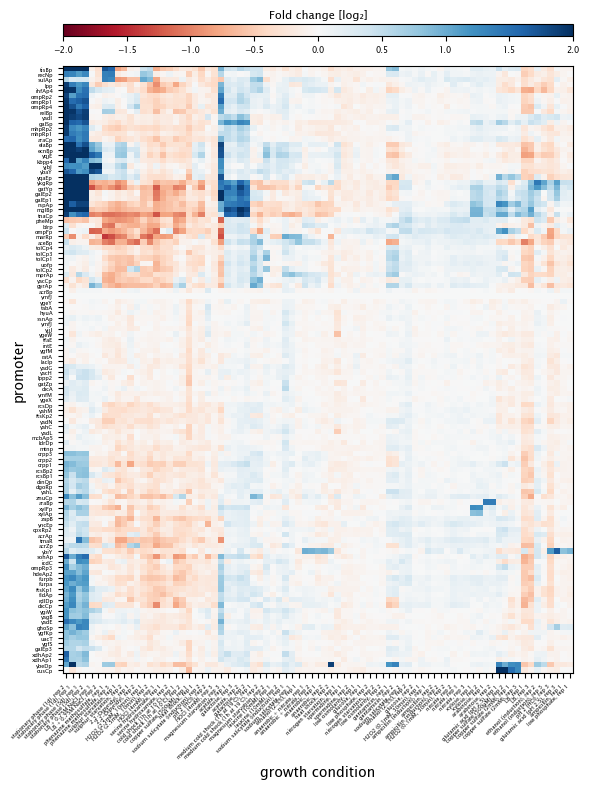

In [17]:
# compute log of fold change
df_norm['log_A'] = np.log2(df_norm['A_norm'])

# reshape dataframe
pivot_df = df_norm.pivot(index='promoter', columns='gc', values='log_A')

# Perform hierarchical clustering on rows (promoters)
row_linkage = linkage(pdist(pivot_df.values, metric='euclidean'), method='ward')
row_order = leaves_list(row_linkage)

# Perform hierarchical clustering on columns (gc)
col_linkage = linkage(pdist(pivot_df.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_linkage)

# Reorder the matrix based on clustering
clustered_df = pivot_df.iloc[row_order, col_order]

# Simple clustered heatmap without dendrograms
fig, ax = plt.subplots(figsize=(6, 8))

# Create pcolormesh of clustered data
im = ax.pcolormesh(clustered_df.values, cmap='RdBu', vmax=2, vmin=-2)

# Set labels
labels = [x_label_names(x) for x in clustered_df.columns]
ax.set_xticks(np.arange(len(clustered_df.columns)) + 0.5, labels , fontsize=4, rotation=45, ha='right')


labels = [tss_names[x] if x in tss_names.keys() else x for x in clustered_df.index]
labels = [x.split('_')[0] for x in labels]
ax.set_yticks(np.arange(len(clustered_df.index)) + 0.5, labels, fontsize=4,)

ax.set_xlabel('growth condition')
ax.set_ylabel('promoter')

# Add colorbar
# Create horizontal colorbar at the top
divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="2%", pad=0.3)  # size controls height
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Fold change [log₂]', fontsize=8)
cbar.ax.tick_params(labelsize=6)

# Move the label to the top
cbar.ax.xaxis.set_label_position('top')
ax.grid(False)
plt.grid(False)
plt.tight_layout()

#fig.savefig('expression_shift_global_SI.pdf')

Next we make a summarized version where we compute the mean of the replicates for each condition.

['stationary phase (1d)', 'stationary phase (3d)', 'LB', 'pH 2 (HCl)', 'phenazine methosulfate', 'cold shock (1h at 10 C)', 'H2O2 (2.5mM, 10min)', 'HOCl (4mM)', 'serine hydroxamate', 'sulphur starvation', '2,2-Dipyridyl', 'acetate', 'galactose', 'magnesium starvation', 'LB + 0.75M NaCl', 'copper sulfate (500µM)', 'glutamic acid (pH 2.5)', 'copper sulfate (2mM)', 'ethanol (induction)', 'xylose', 'arabinose', 'sodium salicytate (induction)', 'heat shock', 'leucine (10mM)', 'anaerobic', 'anaerobic + nitrate', 'sodium salicytate', 'ethanol (2.5%)', 'nitrate', 'H2O2 (0.1mM, 30min)', 'ampicillin (induction)', 'ampicillin', 'low phosphate', 'nitrogen starvation', 'spermidine', 'glucose', 'low osmolarity', 'medium cold shock (1h at 19 C)', 'gentamicin']


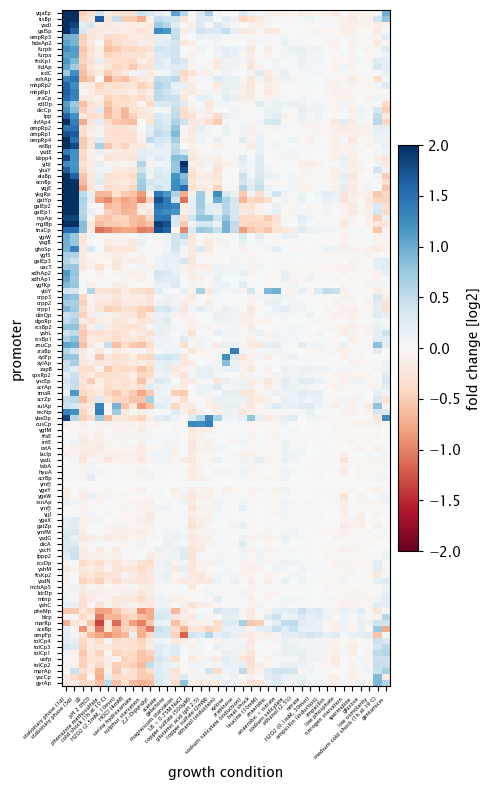

In [56]:
def x_label_names2(x):
    
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}"

df_norm['log_A'] = np.log2(df_norm['A_norm'])
df_norm['G'] = [x.split('-')[0] for x in df_norm.gc]
_df = df_norm.groupby(['promoter', 'G'])['log_A'].apply('mean').reset_index()

pivot_df = _df.pivot(index='promoter', columns='G', values='log_A')

row_linkage = linkage(pdist(pivot_df.values, metric='euclidean'), method='ward')
row_order = leaves_list(row_linkage)

# Perform hierarchical clustering on columns (gc)
col_linkage = linkage(pdist(pivot_df.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_linkage)

# Reorder the matrix based on clustering
clustered_df = pivot_df.iloc[row_order, col_order]

# Simple clustered heatmap without dendrograms
fig, ax = plt.subplots(figsize=(5, 8))

# Create pcolormesh of clustered data
im = ax.pcolormesh(clustered_df.values, cmap='RdBu', vmax=2, vmin=-2)

# Set labels
labels = [x_label_names2(x) for x in clustered_df.columns]
print(labels)
ax.set_xticks(np.arange(len(clustered_df.columns)) + 0.5, labels , fontsize=4, rotation=45, ha='right')


labels = [tss_names[x] if x in tss_names.keys() else x for x in clustered_df.index]
labels = [x.split('_')[0] for x in labels]
ax.set_yticks(np.arange(len(clustered_df.index)) + 0.5, labels, fontsize=4,)

ax.set_xlabel('growth condition')
ax.set_ylabel('promoter')

# Add colorbar
plt.colorbar(im, ax=ax, label='fold change [log2]', shrink=0.6, pad=0.02)
ax.grid(False)
plt.grid(False)
plt.tight_layout()

#fig.savefig('expression_shift_global.pdf')

Finally, we add another subplot that shows the median of relative expression for each promoter, to show if the promoter is expressing on a high or low level in general.

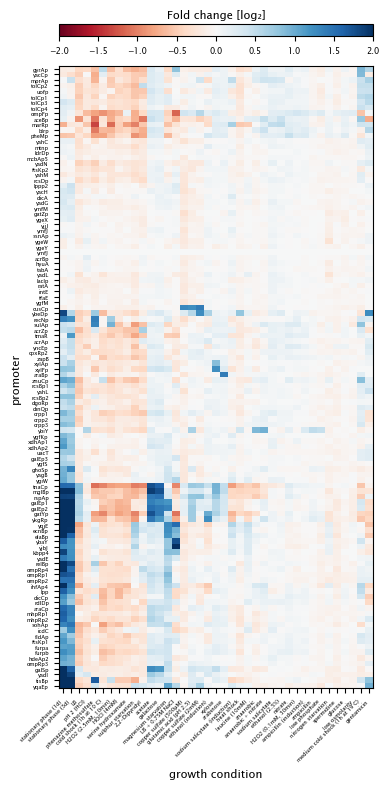

In [57]:
def x_label_names2(x):
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}"

#df_norm['log_A'] = np.log2(df_norm['A_f'])
df_norm['G'] = [x.split('-')[0] for x in df_norm.gc]
#_df = df_norm[[x not in ['7-1', '7-2', '8-1', '8-2'] for x in df_norm['gc'].values]]
_df = df_norm
_df = _df.groupby(['promoter', 'G'])['log_A'].apply('mean').reset_index()
pivot_df = _df.pivot(index='promoter', columns='G', values='log_A')

# Hierarchical clustering
row_linkage = linkage(pdist(pivot_df.values, metric='euclidean'), method='ward')
row_order = leaves_list(row_linkage)
col_linkage = linkage(pdist(pivot_df.values.T, metric='euclidean'), method='ward')
col_order = leaves_list(col_linkage)

# Reorder the matrix based on clustering
clustered_df = pivot_df.iloc[row_order, col_order]

# Prepare data for bar plot - reorder to match heatmap
df_exp = df_norm.groupby('promoter')['A'].apply('median').reset_index()
df_exp = df_exp.set_index('promoter').loc[clustered_df.index].reset_index()

# Create figure with two subplots
fig, ax1 = plt.subplots(1, 1, figsize=(4, 8))

# Left panel: Heatmap
im = ax1.pcolormesh(clustered_df.values, cmap='RdBu', vmax=2, vmin=-2)

# Set heatmap labels
x_labels = [x_label_names2(x) for x in clustered_df.columns]
ax1.set_xticks(np.arange(len(clustered_df.columns)) + 0.5, x_labels, fontsize=4, rotation=45, ha='right')
y_labels = [tss_names[x] if x in tss_names.keys() else x for x in clustered_df.index]
y_labels = [x.split('_')[0] for x in y_labels]
ax1.set_yticks(np.arange(len(clustered_df.index)) + 0.5, y_labels, fontsize=4)
ax1.set_xlabel('growth condition', fontsize=8)
ax1.set_ylabel('promoter', fontsize=8)
ax1.invert_yaxis()
ax1.grid(False)

# Create horizontal colorbar at the top of heatmap
divider = make_axes_locatable(ax1)
cax = divider.append_axes("top", size="2%", pad=0.3)
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Fold change [log₂]', fontsize=8)
cbar.ax.tick_params(labelsize=6)
cbar.ax.xaxis.set_label_position('top')

# Remove y-axis labels from bar plot since they're redundant with heatmap
#ax2.set_yticklabels([])

plt.tight_layout()
#fig.savefig('expression_shift_global_main_single.pdf')

In [48]:
def x_label_names2(x):
    cond = df_gc.loc[df_gc['Index'] == int(x.split('-')[0]), "Condition"].values[0]
    return f"{cond}"

#df_norm['log_A'] = np.log2(df_norm['A_f'])
df_norm['G'] = [x.split('-')[0] for x in df_norm.gc]
_df = df_norm[[x not in ['7-1', '7-2', '8-1', '8-2'] for x in df_norm['gc'].values]]
_df = _df.groupby(['promoter', 'G'])['log_A'].apply('mean').reset_index()
_df

,promoter,G,log_A
0,TSS_1414_storz_regulondb,1,0.000963
1,TSS_1414_storz_regulondb,10,0.001085
2,TSS_1414_storz_regulondb,11,-0.141482
3,TSS_1414_storz_regulondb,12,0.049367
4,TSS_1414_storz_regulondb,13,-0.193787
...,...,...,...
4139,znuCp,40,0.227980
4140,znuCp,41,0.192528
4141,znuCp,5,0.060339
4142,znuCp,6,-0.007383


In [49]:
clustered_df.iloc[[x in promoters for x in clustered_df.index]]

G,7,8,13,22,25,9,28,31,33,16,...,12,18,10,37,14,32,1,35,23,29
promoter,,,,,,,,,,,,,,,,,,,,,
yqjE_yqjK_yqjD_yqjC_predicted,2.487676,2.216809,-0.800953,-0.253766,0.114748,-0.390065,-0.299602,-0.259098,-0.437445,0.746200,...,-0.088010,-0.015074,-0.004669,-0.123703,0.217980,-0.182866,-0.035222,0.083831,0.024075,-0.567514
ecnBp,2.245471,1.982440,-0.620113,-0.193829,0.266202,-0.282262,-0.206042,-0.190826,-0.266123,0.696037,...,-0.041154,-0.014474,-0.004556,-0.073254,0.141230,-0.154467,-0.048311,0.061977,-0.033113,-0.342886
elaBp,2.122953,1.617184,-0.568575,-0.227560,0.132170,-0.287014,-0.265368,-0.280988,-0.401487,0.596918,...,-0.080104,-0.025137,-0.010877,-0.150465,0.188159,-0.237094,-0.022005,0.008659,0.089366,-0.510502
ybaY_predicted,1.655475,1.190313,-0.409491,-0.155463,0.082037,0.054518,-0.179448,-0.182696,-0.230031,0.408838,...,-0.059446,-0.045458,-0.040097,-0.112030,0.086297,-0.112728,-0.078614,-0.037068,0.391781,-0.073388
yjbJ_predicted,1.250121,1.178267,-0.295913,-0.170632,0.182775,-0.077374,-0.108781,-0.041290,-0.114792,0.605234,...,-0.134884,-0.079249,0.014499,0.022238,0.125260,-0.150060,-0.076775,0.006084,0.095816,-0.198188
kbpp4,1.846429,1.203279,-0.427449,-0.152454,0.020834,-0.282022,-0.199580,-0.191924,-0.279296,0.280010,...,-0.034263,0.010523,-0.007071,-0.097323,0.141241,-0.118707,0.003826,0.009950,-0.114397,-0.241592


In [58]:
def plot_headmap(_df, promoters):
    # Data processing
    pivot_df = _df.pivot(index='promoter', columns='G', values='log_A')

    # Filter: Keep rows that are in the promoters list (maintaining cluster order)
    df_filtered = pivot_df.iloc[[x in promoters for x in pivot_df.index]]

    # Hierarchical clustering
    row_linkage = linkage(pdist(df_filtered.values, metric='cosine'), method='average')
    row_order = leaves_list(row_linkage)
    col_linkage = linkage(pdist(df_filtered.values.T, metric='cosine'), method='average')
    col_order = leaves_list(col_linkage)

    # Reorder the matrix based on clustering
    clustered_df = df_filtered.iloc[row_order, col_order]
    
    # Filter: Keep rows that are in the promoters list (maintaining cluster order)
    df_filtered = clustered_df.iloc[[x in promoters for x in clustered_df.index]]

    # --- DYNAMIC SIZE CALCULATION ---
    n_rows, n_cols = df_filtered.shape
    
    # Tunable parameter: size of one square cell in inches
    cell_size = 0.05
    
    # Margins for labels (in inches). Adjust 'bottom' if x-labels are long.
    margin_left = 1.5   # Space for promoter names
    margin_bottom = 2.0 # Space for rotated condition labels
    margin_right = 0.2
    margin_top = 0.2
    
    # Calculate total figure size
    fig_width = (n_cols * cell_size) + margin_left + margin_right
    fig_height = (n_rows * cell_size) + margin_bottom + margin_top
    
    # Create figure with calculated dimensions
    fig, ax1 = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    # -------------------------------

    # Heatmap
    im = ax1.pcolormesh(df_filtered.values, cmap='RdBu', vmax=2, vmin=-2)
    
    # Force the axes to maintain square cells
    ax1.set_aspect('equal', adjustable='box')

    # Labels and Ticks
    x_labels = [x_label_names2(x) for x in df_filtered.columns]
    ax1.set_xticks(np.arange(len(df_filtered.columns)) + 0.5)
    ax1.set_xticklabels(x_labels, fontsize=4, rotation=45, ha='right')
    
    y_labels = [tss_names[x] if x in tss_names.keys() else x for x in df_filtered.index]
    y_labels = [x.split('_')[0] for x in y_labels]
    ax1.set_yticks(np.arange(len(df_filtered.index)) + 0.5)
    ax1.set_yticklabels(y_labels, fontsize=4)
    
    ax1.set_xlabel('growth condition', fontsize=8)
    ax1.set_ylabel('promoter', fontsize=8)
    
    ax1.invert_yaxis()
    ax1.grid(False)

    # Tight layout helps fit the labels into the margins defined by figsize
    plt.tight_layout()
    
    # fig.savefig('expression_shift_global_main_single.pdf')
    return fig, ax1

(<Figure size 365x260 with 1 Axes>,
 <Axes: xlabel='growth condition', ylabel='promoter'>)

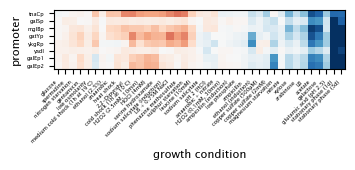

In [59]:
promoters = ['galEp1', 'galEp2', 'galSp', 'gatYp', 'ykgRp', 'tnaCp', 'mglBp', 'rpsAp', 'yadI_predicted']
plot_headmap(_df, promoters)

(<Figure size 365x245 with 1 Axes>,
 <Axes: xlabel='growth condition', ylabel='promoter'>)

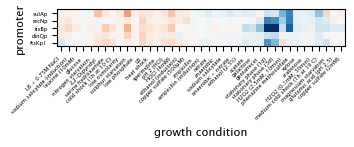

In [60]:
promoters = ['tisBp', 'sulAp', 'recNp', 'dinQp', 'ftsKp1', '']
plot_headmap(_df, promoters)

(<Figure size 365x250 with 1 Axes>,
 <Axes: xlabel='growth condition', ylabel='promoter'>)

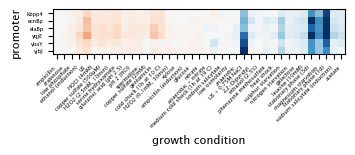

In [61]:
promoters = ['yjbJ_predicted', 'ybaY_predicted', 'yqjE_yqjK_yqjD_yqjC_predicted', 'kbpp4', 'ecnBp', 'elaBp']
plot_headmap(_df, promoters)

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def plot_heatmap_ranking(
    _df,
    promoters=None,
    conditions=None,
    top_promoters=None,     # NEW: int or None
    swap_axes=False,        # NEW: bool
    width_scale=1.25
):
    # --- 0. OPTIONAL PRE-FILTERING ON CONDITIONS FOR SCORING ---
    df_work = _df
    if conditions is not None:
        # conditions refer to growth condition labels in column 'G'
        df_work = df_work[df_work["G"].isin(conditions)]

    # --- 1. OPTIONAL FILTERING ON PROMOTERS ---
    if promoters is not None:
        df_work = df_work[df_work["promoter"].isin(promoters)]

    # --- 2. KEEP ONLY TOP X PROMOTERS BY EXPRESSION ---
    if top_promoters is not None:
        # Mean expression per promoter across (filtered) conditions
        promoter_score = df_work.groupby("promoter")["log_A"].mean().sort_values(ascending=False)
        top_set = promoter_score.head(int(top_promoters)).index
        df_work = df_work[df_work["promoter"].isin(top_set)]

    # --- 3. PIVOT ---
    if not swap_axes:
        pivot_df = df_work.pivot(index="promoter", columns="G", values="log_A")
        # If conditions were supplied, enforce column order (and drop missing)
        if conditions is not None:
            pivot_df = pivot_df.reindex(columns=list(conditions))
    else:
        pivot_df = df_work.pivot(index="G", columns="promoter", values="log_A")
        # If conditions were supplied, enforce row order (and drop missing)
        if conditions is not None:
            pivot_df = pivot_df.reindex(index=list(conditions))

    # --- 4. RANKING (BOTH AXES BY MEAN) ---
    row_score = pivot_df.mean(axis=1)
    col_score = pivot_df.mean(axis=0)

    sorted_rows = row_score.sort_values(ascending=False).index
    sorted_cols = col_score.sort_values(ascending=False).index

    df_final = pivot_df.loc[sorted_rows, sorted_cols]

    # --- 5. EXACT GEOMETRY CALCULATION ---
    n_rows, n_cols = df_final.shape

    cell_height = 0.125
    cell_width = cell_height * width_scale

    margin_left = 1.5
    margin_bottom = 2.0
    margin_right = 0.2
    margin_top = 0.2

    plot_width_inches = n_cols * cell_width
    plot_height_inches = n_rows * cell_height

    fig_width = margin_left + plot_width_inches + margin_right
    fig_height = margin_bottom + plot_height_inches + margin_top

    fig = plt.figure(figsize=(fig_width, fig_height))

    ax_left = margin_left / fig_width
    ax_bottom = margin_bottom / fig_height
    ax_width = plot_width_inches / fig_width
    ax_height = plot_height_inches / fig_height

    ax1 = fig.add_axes([ax_left, ax_bottom, ax_width, ax_height])

    # --- 6. PLOTTING ---
    im = ax1.pcolormesh(df_final.values, cmap="RdBu_r", vmax=2, vmin=-2)
    ax1.set_aspect(1.0 / width_scale)

    # --- 7. TICKS + LABELS ---
    if not swap_axes:
        # X: conditions
        x_labels = [x_label_names2(x) for x in df_final.columns]
        ax1.set_xticks(np.arange(len(df_final.columns)) + 0.5)
        ax1.set_xticklabels(x_labels, fontsize=8, rotation=45, ha="right")

        # Y: promoters
        y_labels = [tss_names[x] if x in tss_names else x for x in df_final.index]
        y_labels = [x.split("_")[0] for x in y_labels]
        ax1.set_yticks(np.arange(len(df_final.index)) + 0.5)
        ax1.set_yticklabels(y_labels, fontsize=8)

        ax1.set_xlabel("growth condition", fontsize=8)
        ax1.set_ylabel("promoter", fontsize=8)
    else:
        # X: promoters
        x_labels = [tss_names[x] if x in tss_names else x for x in df_final.columns]
        x_labels = [x.split("_")[0] for x in x_labels]
        ax1.set_xticks(np.arange(len(df_final.columns)) + 0.5)
        ax1.set_xticklabels(x_labels, fontsize=8, rotation=45, ha="right")

        # Y: conditions
        y_labels = [x_label_names2(x) for x in df_final.index]
        ax1.set_yticks(np.arange(len(df_final.index)) + 0.5)
        ax1.set_yticklabels(y_labels, fontsize=8)

        ax1.set_xlabel("promoter", fontsize=8)
        ax1.set_ylabel("growth condition", fontsize=8)

    ax1.invert_yaxis()
    ax1.grid(False)

    return fig, ax1


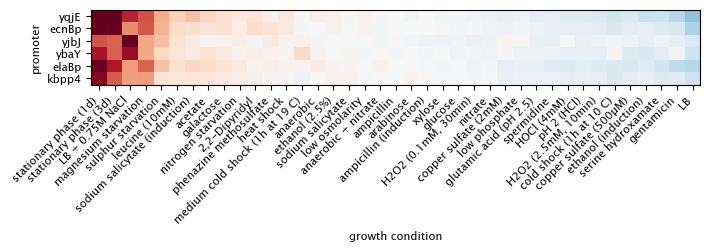

In [71]:
promoters = ['yjbJ_predicted', 'ybaY_predicted', 'yqjE_yqjK_yqjD_yqjC_predicted', 'kbpp4', 'ecnBp', 'elaBp']
fig, ax = plot_heatmap_ranking(_df, promoters, width_scale=1.25)

#fig.savefig('pdf_files/salt_heatmap.pdf')

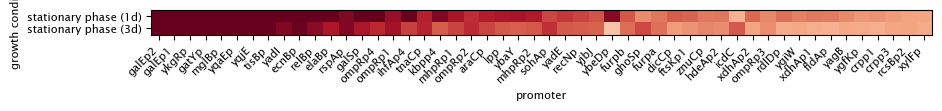

In [76]:
fig, ax =plot_heatmap_ranking(_df, conditions=['7', '8'], top_promoters=50, swap_axes=True)
fig.savefig('pdf_files/stat_phase_expression.pdf')

(<Figure size 195x1620 with 1 Axes>, <Axes: >)

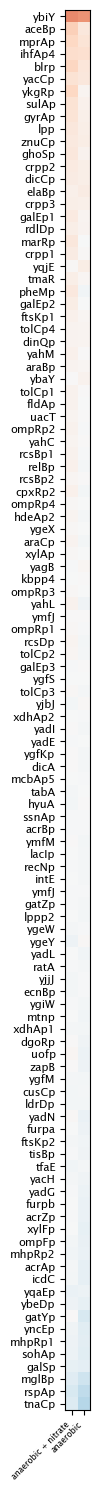

In [56]:
conditions = ['34', '41']
plot_headmap_ranking(_df, conditions=conditions)

(<Figure size 182.5x1620 with 1 Axes>, <Axes: >)

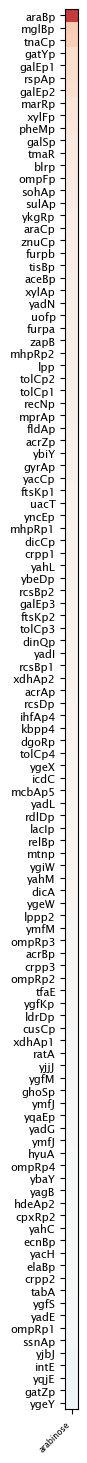

In [57]:
conditions = ['3']
plot_headmap_ranking(_df, conditions=conditions)

Index(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2',
       '20', '21', '22', '23', '24', '25', '28', '29', '3', '30', '31', '32',
       '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '5', '6',
       '7', '8', '9'],
      dtype='object', name='G')


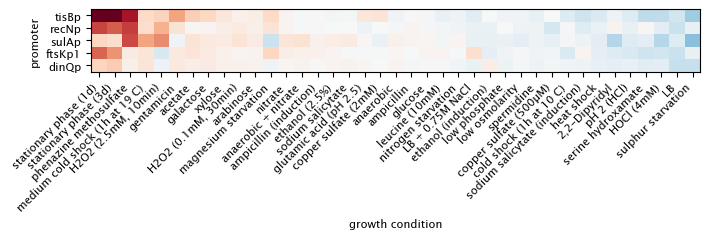

In [66]:
promoters = ['tisBp', 'sulAp', 'recNp', 'dinQp', 'ftsKp1', '']
fig, ax = plot_heatmap_ranking(_df, promoters, width_scale=1.25)
#fig.savefig('pdf_files/lexA_heatmap.pdf')

Index(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2',
       '20', '21', '22', '23', '24', '25', '28', '29', '3', '30', '31', '32',
       '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '5', '6',
       '7', '8', '9'],
      dtype='object', name='G')


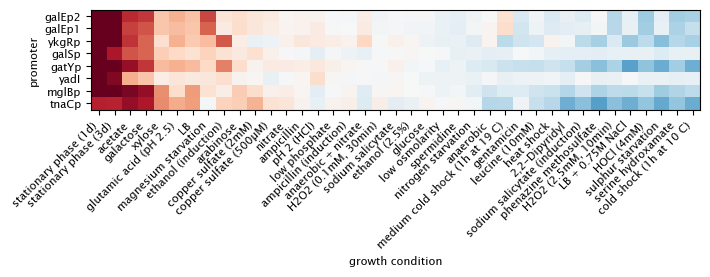

In [68]:
promoters = ['galEp1', 'galEp2', 'galSp', 'gatYp', 'ykgRp', 'tnaCp', 'mglBp', 'rpsAp', 'yadI_predicted']
fig, ax = plot_heatmap_ranking(_df, promoters, width_scale=1.25)

fig.savefig('pdf_files/CRP_heatmap_extended.pdf')

(<Figure size 632.5x245 with 1 Axes>, <Axes: >)

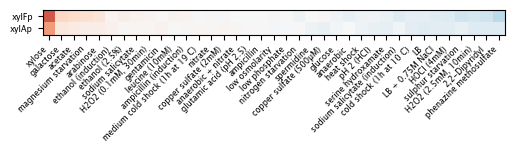

In [28]:
promoters = ['xylAp', 'xylFp']
plot_headmap_ranking(_df, promoters)

(<Figure size 632.5x245 with 1 Axes>, <Axes: >)

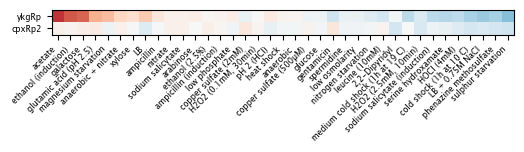

In [29]:
promoters = ['ykgRp', 'cpxRp2']
plot_headmap_ranking(_df, promoters)

(<Figure size 632.5x257.5 with 1 Axes>, <Axes: >)

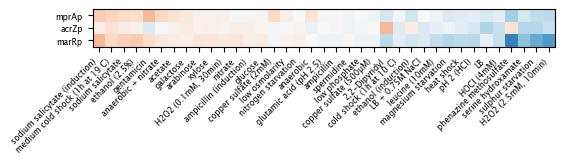

In [30]:
promoters = ['acrZp', 'mprAp', 'marRp']
plot_headmap_ranking(_df, promoters)

(<Figure size 779.375x1620 with 1 Axes>,
 <Axes: xlabel='growth condition', ylabel='promoter'>)

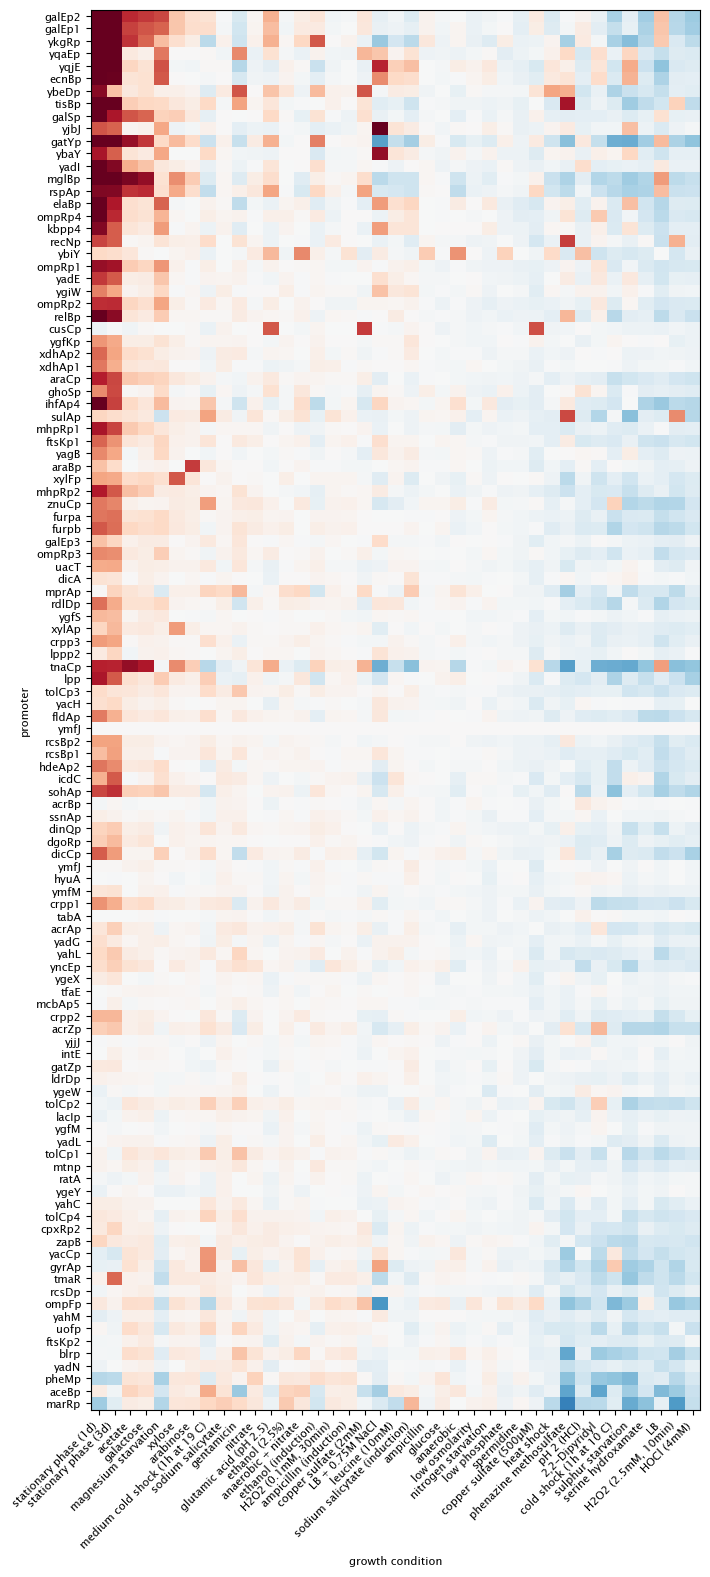

In [27]:
df_norm['G'] = [x.split('-')[0] for x in df_norm.gc]
df_all = df_norm.groupby(['promoter', 'G'])['log_A'].apply('mean').reset_index()

plot_heatmap_ranking(df_all)

In [19]:
df_norm

,promoter,A,gc,A_norm,G
0,TSS_1414_storz_regulondb,0.795614,1-1,0.989972,1
1,TSS_18061_regulondb,0.528909,1-1,0.928264,1
2,TSS_4654_wanner_regulondb,0.543657,1-1,1.000000,1
3,TSS_4655_regulondb,0.522168,1-1,0.945793,1
4,TSS_6311_regulondb,0.538782,1-1,0.962127,1
...,...,...,...,...,...
107,yncEp,0.881077,9-2,0.776999,9
108,yqaEp,0.868776,9-2,0.904784,9
109,yqjE_yqjK_yqjD_yqjC_predicted,0.927881,9-2,0.749838,9
110,zapB_predicted,0.992816,9-2,0.681011,9
